# Q2 — Unsupervised Learning

# TASK- 1

# Data Preparation 

In [21]:


import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('../data/q2_customers.csv')

df.head()




,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


# Scaling

In [22]:


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


Scaling is essential before applying K-Means because the algorithm is distance-based.
Features with larger values (e.g., annual_spend) can dominate smaller-scale features 
(e.g., visits_per_month), leading to biased clustering. StandardScaler ensures all 
features contribute equally.


# TASK-2

#  Choosing K

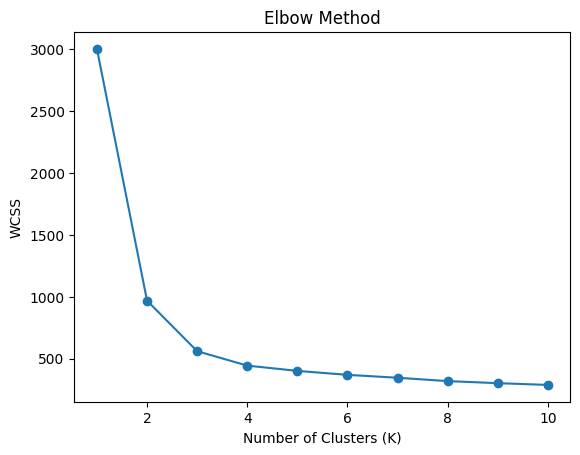

In [23]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()



The elbow point is observed at K = 3, where the decrease in WCSS starts to slow down significantly.

From K = 1 to K = 3, there is a sharp reduction in WCSS, indicating that adding clusters improves the clustering performance. However, beyond K = 3, the decrease in WCSS becomes gradual, showing diminishing returns.

Therefore, K = 3 is selected as the optimal number of clusters as it provides a good balance between model performance and complexity.


# TASK -3 

# K-Means Clustering

# Choose K (example: 3)

In [24]:

k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column
df['cluster'] = clusters

df.head()



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


# Centroids

In [25]:


centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.drop('cluster', axis=1).columns
)

centroids


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0: High spenders with frequent visits → loyal premium customers  
Cluster 1: Low spenders with infrequent visits → occasional customers  
Cluster 2: Moderate spenders with medium visits → regular customers  

This segmentation helps businesses target marketing strategies effectively.


# TASK- 4

# PCA (Dimensionality Reduction)


In [26]:

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)





# Explained Variance

In [27]:


print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.83560354 0.05568764]


# Feature Loadings

In [28]:


loadings = pd.DataFrame(
    pca.components_,
    columns=df.drop('cluster', axis=1).columns,
    index=['PC1', 'PC2']
)

loadings


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 captures the majority of the variance (around 83%), indicating that it represents the overall customer behavior. 
It has strong positive contributions from features like age, annual_spend, and basket_size, suggesting it reflects overall spending capacity and purchasing behavior.

PC2 captures a smaller portion of the variance (around 5%) and is mainly influenced by days_since_last_visit and visits_per_month. 
This indicates that PC2 represents customer engagement and visit patterns.

Overall, PC1 represents spending behavior, while PC2 captures customer activity and engagement.


# TASK - 5

# Cluster Visualisation

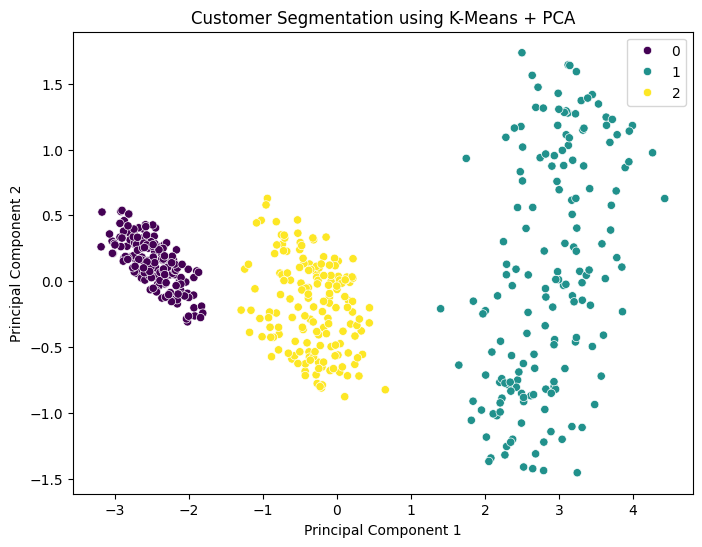

In [29]:


import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['cluster'],
    palette='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means + PCA")
plt.legend()
plt.show()


This clustering approach enables targeted marketing, personalized recommendations,
and improved customer retention strategies.
